<a href="https://colab.research.google.com/github/yemioz/Numerical-Methods-Projects/blob/main/ode-euler-runge-kutta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ordinary Differential Equations with Euler's method and Runge-Kutta 4th order method.

Below are imported packages that will support the functions and expressions needed for the coding throughout this project.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy
import pandas as pd

Using our original function from Project Part 1: $$f(x)=4e^{-x}$$

We will solve
$$\frac{dy}{dx}=4e^{-x}(1-y), \text{ } y(0)=2$$

In [ ]:
function = lambda x: 4*np.exp(-x)

The solution is of the form
$$y(x)=1+ce^{-\int 4e^{-x}dx}$$

We need to solve for $c$, using the fact that $y(0)=2$. We have,
$$y(0)=1+ce^{4}$$
$$c=e^{-4}$$
Thus, our solution is
$$y(x) = 1+e^{-4(1-e^{-x})}$$

We will now graph this below.

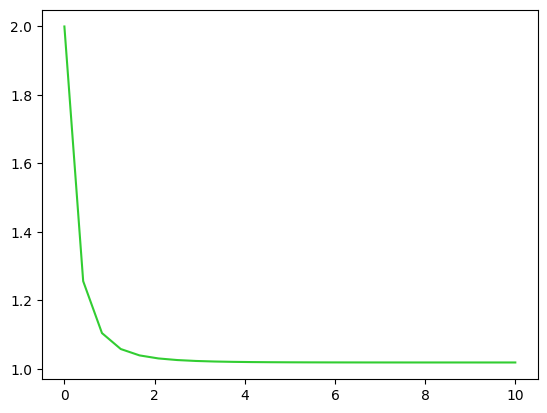

In [ ]:
y = lambda x: 1+np.exp(-4*(1-np.exp(-x)))
interval = np.linspace(0, 10, 25)

plt.plot(interval, y(interval), '#32CD32')

###Euler's Method


We will create an algorithm to perform the Euler Method. This is given by the following formula: $$y_{i+1}=y_i+f(x_i,y_i)h$$ Where $h$ is our step size.

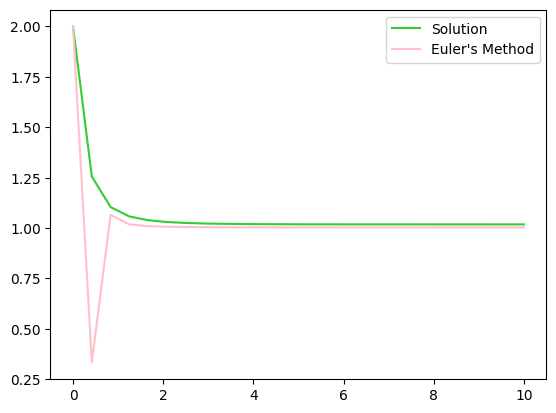

In [ ]:
func_xy = lambda x,y: 4*np.exp(-x)*(1-y)
def Euler(function, initial_value, interval):
  y_list = []
  y = initial_value
  step = interval[1]-interval[0]
  for i in interval:
    y_list.append([y])
    y = y + function(i, y)*step
  return np.array(y_list)

solution = Euler(func_xy, 2, interval)
plt.plot(interval, y(interval), '#32CD32')
plt.plot(interval, solution, 'pink')
plt.legend(['Solution', "Euler's Method"])

Above is the graph of our analytic solution and our numerical solution.

###Runge-Kutta

We will now program an algorithm to perform the Runge-Kutta 4th order method.


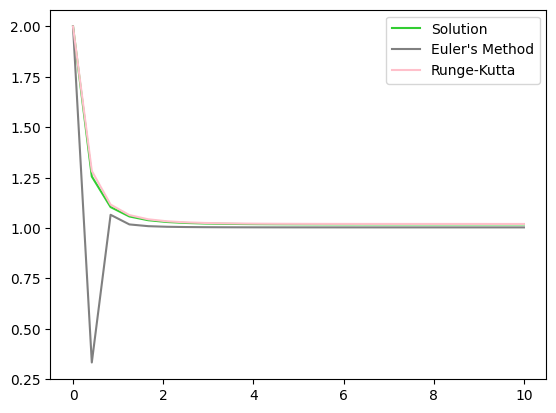

In [ ]:
def Runge_Kutta(function, initial_value, interval):
  step = interval[1] - interval[0]
  y = initial_value
  solution = []
  for i in interval:
    solution.append([y])
    k1 = function(i, y)
    k2 = function(i+step/2, y+k1*step/2)
    k3 = function(i+step/2, y+k2*step/2)
    k4 = function(i+step, y+k3*step)
    y = y + step/6*(k1+2*k2+2*k3+k4)
  return np.array(solution)

kutta_solution = Runge_Kutta(func_xy, 2, interval)

plt.plot(interval, y(interval), '#32CD32')
plt.plot(interval, solution, color = 'grey')
plt.plot(interval, kutta_solution, color = 'pink')
plt.legend(['Solution', "Euler's Method", 'Runge-Kutta'])

Above is the graph of our three different solutions.



###Findings


The work above shows us that Runge-Kutta method got closer to our function than Euler's method.

It seems like our numerical methods were correctly coded, although the spike at step 1 for Euler's is concerning. After testing some other values for the increment, it seems like this is correct for Euler's method, since other increments show a much more normal looking graph. We decided that the graphs looked more interesting and showed the difference in approximations and accuracy more in the example above, so we decided to keep it this way.

It seems like the Runge-Kutta method is actually just more complex than the Euler method, rather than the two being comparable and contrastable. The Runge-Kutta uses several formulas that are very similar to the one found in Euler's before finding the new value of y.